In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

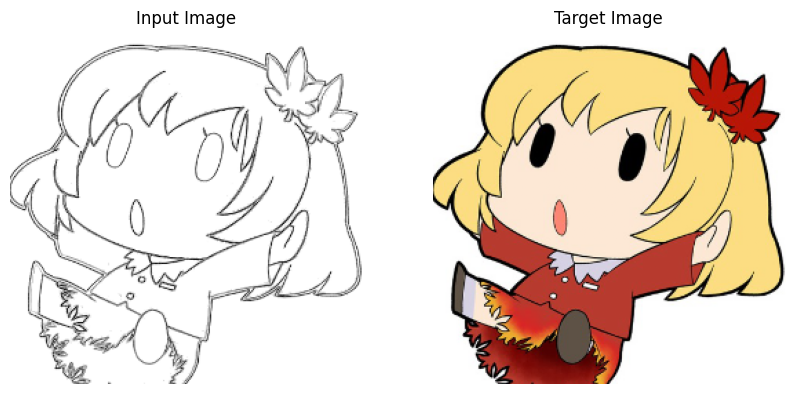

Input Shape : (8, 256, 256, 3)
Target Shape: (8, 256, 256, 3)


In [15]:
# ============================================
# PIX2PIX DATASET PIPELINE (TENSORFLOW)
# ============================================

import tensorflow as tf
import matplotlib.pyplot as plt

# ============================================
# CONFIG
# ============================================

IMG_WIDTH = 256
IMG_HEIGHT = 256
BATCH_SIZE = 8

TRAIN_PATH = "/kaggle/input/datasets/ktaebum/anime-sketch-colorization-pair/data/train/*.png"
VAL_PATH = "/kaggle/input/datasets/ktaebum/anime-sketch-colorization-pair/data/train/*.png"

# ============================================
# LOAD IMAGE
# ============================================

def load_image(image_file):

    image = tf.io.read_file(image_file)

    image = tf.io.decode_image(
        image,
        channels=3
    )
    image.set_shape([None, None, 3])

    # Split image into input and target
    w = tf.shape(image)[1] // 2

    target_image = image[:, :w, :]
    input_image = image[:, w:, :]

    input_image = tf.cast(input_image, tf.float32)
    target_image = tf.cast(target_image, tf.float32)

    return input_image, target_image


# ============================================
# RESIZE
# ============================================

def resize(input_image, target_image, height, width):

    input_image = tf.image.resize(
        input_image,
        [height, width]
    )

    target_image = tf.image.resize(
        target_image,
        [height, width]
    )

    return input_image, target_image


# ============================================
# RANDOM CROP
# ============================================

def random_crop(input_image, target_image):

    stacked_image = tf.stack(
        [input_image, target_image],
        axis=0
    )

    cropped_image = tf.image.random_crop(
        stacked_image,
        size=[2, IMG_HEIGHT, IMG_WIDTH, 3]
    )

    return cropped_image[0], cropped_image[1]


# ============================================
# NORMALIZE [-1, 1]
# ============================================

def normalize(input_image, target_image):

    input_image = (input_image / 127.5) - 1
    target_image = (target_image / 127.5) - 1

    return input_image, target_image


# ============================================
# RANDOM JITTER
# Official Pix2Pix Augmentation
# ============================================

def random_jitter(input_image, target_image):

    # Resize to 286x286
    input_image, target_image = resize(
        input_image,
        target_image,
        286,
        286
    )

    # Random crop back to 256x256
    input_image, target_image = random_crop(
        input_image,
        target_image
    )

    # Random horizontal flip
    if tf.random.uniform(()) > 0.5:

        input_image = tf.image.flip_left_right(
            input_image
        )

        target_image = tf.image.flip_left_right(
            target_image
        )

    return input_image, target_image


# ============================================
# TRAIN IMAGE LOADER
# ============================================

def load_image_train(image_file):

    input_image, target_image = load_image(
        image_file
    )

    input_image, target_image = random_jitter(
        input_image,
        target_image
    )

    input_image, target_image = normalize(
        input_image,
        target_image
    )

    return input_image, target_image


# ============================================
# TEST IMAGE LOADER
# ============================================

def load_image_test(image_file):

    input_image, target_image = load_image(
        image_file
    )

    input_image, target_image = resize(
        input_image,
        target_image,
        IMG_HEIGHT,
        IMG_WIDTH
    )

    input_image, target_image = normalize(
        input_image,
        target_image
    )

    return input_image, target_image


# ============================================
# BUILD TRAIN DATASET
# ============================================

train_dataset = tf.data.Dataset.list_files(
    TRAIN_PATH
)

train_dataset = train_dataset.map(
    load_image_train,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_dataset = train_dataset.shuffle(
    400
)

train_dataset = train_dataset.batch(
    BATCH_SIZE
)

train_dataset = train_dataset.prefetch(
    tf.data.AUTOTUNE
)


# ============================================
# BUILD TEST DATASET
# ============================================

test_dataset = tf.data.Dataset.list_files(
    VAL_PATH
)

test_dataset = test_dataset.map(
    load_image_test,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_dataset = test_dataset.batch(
    BATCH_SIZE
)

test_dataset = test_dataset.prefetch(
    tf.data.AUTOTUNE
)


# ============================================
# VISUALIZE SAMPLE
# ============================================

for input_image, target_image in train_dataset.take(1):

    plt.figure(figsize=(10, 5))

    # INPUT IMAGE
    plt.subplot(1, 2, 1)

    plt.imshow(
        (input_image[0] + 1) / 2
    )

    plt.title("Input Image")

    plt.axis("off")

    # TARGET IMAGE
    plt.subplot(1, 2, 2)

    plt.imshow(
        (target_image[0] + 1) / 2
    )

    plt.title("Target Image")

    plt.axis("off")

    plt.show()

    print("Input Shape :", input_image.shape)
    print("Target Shape:", target_image.shape)

In [16]:
# ============================================
# PIX2PIX CONFIG FILE (TENSORFLOW VERSION)
# ============================================

import tensorflow as tf

# ============================================
# DEVICE
# ============================================

DEVICE = "GPU" if tf.config.list_physical_devices('GPU') else "CPU"

# ============================================
# DATA PATHS
# ============================================

TRAIN_DIR = "/kaggle/input/datasets/ktaebum/anime-sketch-colorization-pair/data/train/*.png"
VAL_DIR = "/kaggle/input/datasets/ktaebum/anime-sketch-colorization-pair/data/val/*.png"

# ============================================
# TRAINING HYPERPARAMETERS
# ============================================

LEARNING_RATE = 2e-4

BATCH_SIZE = 16

IMAGE_SIZE = 256

CHANNELS_IMG = 3

L1_LAMBDA = 100

LAMBDA_GP = 10

NUM_EPOCHS = 50

LOAD_MODEL = False

SAVE_MODEL = False

CHECKPOINT_DISC = "disc.weights.h5"

CHECKPOINT_GEN = "gen.weights.h5"

# ============================================
# AUTOTUNE
# ============================================

AUTOTUNE = tf.data.AUTOTUNE

# ============================================
# NORMALIZATION
# Converts [0,255] -> [-1,1]
# ============================================

def normalize(image):

    image = (image / 127.5) - 1

    return image

# ============================================
# RESIZE
# ============================================

def resize(input_image, target_image):

    input_image = tf.image.resize(
        input_image,
        [IMAGE_SIZE, IMAGE_SIZE]
    )

    target_image = tf.image.resize(
        target_image,
        [IMAGE_SIZE, IMAGE_SIZE]
    )

    return input_image, target_image

# ============================================
# RANDOM HORIZONTAL FLIP
# ============================================

def random_flip(input_image, target_image):

    if tf.random.uniform(()) > 0.5:

        input_image = tf.image.flip_left_right(
            input_image
        )

        target_image = tf.image.flip_left_right(
            target_image
        )

    return input_image, target_image

# ============================================
# COLOR JITTER
# Applied ONLY to input image
# ============================================

def color_jitter(input_image):

    input_image = tf.image.random_brightness(
        input_image,
        max_delta=0.2
    )

    input_image = tf.image.random_contrast(
        input_image,
        lower=0.8,
        upper=1.2
    )

    input_image = tf.image.random_saturation(
        input_image,
        lower=0.8,
        upper=1.2
    )

    input_image = tf.image.random_hue(
        input_image,
        max_delta=0.02
    )

    return input_image

# ============================================
# FULL TRAIN TRANSFORM
# ============================================

def train_transform(input_image, target_image):

    # Resize
    input_image, target_image = resize(
        input_image,
        target_image
    )

    # Random flip
    input_image, target_image = random_flip(
        input_image,
        target_image
    )

    # Color jitter ONLY input
    input_image = color_jitter(
        input_image
    )

    # Normalize
    input_image = normalize(
        input_image
    )

    target_image = normalize(
        target_image
    )

    return input_image, target_image

# ============================================
# VALIDATION TRANSFORM
# ============================================

def val_transform(input_image, target_image):

    input_image, target_image = resize(
        input_image,
        target_image
    )

    input_image = normalize(
        input_image
    )

    target_image = normalize(
        target_image
    )

    return input_image, target_image

# ============================================
# PRINT INFO
# ============================================

print("=" * 50)
print("DEVICE:", DEVICE)
print("IMAGE SIZE:", IMAGE_SIZE)
print("BATCH SIZE:", BATCH_SIZE)
print("LEARNING RATE:", LEARNING_RATE)
print("=" * 50)

DEVICE: GPU
IMAGE SIZE: 256
BATCH SIZE: 16
LEARNING RATE: 0.0002


In [5]:
# ============================================
# PIX2PIX UTILS FILE (TENSORFLOW VERSION)
# ============================================

import tensorflow as tf
import matplotlib.pyplot as plt
import os

# ============================================
# SAVE GENERATED EXAMPLES
# ============================================

def save_some_examples(generator, val_dataset, epoch, folder):

    # Create folder if not exists
    os.makedirs(folder, exist_ok=True)

    # Take one batch
    for input_image, target_image in val_dataset.take(1):

        # Generate fake image
        prediction = generator(
            input_image,
            training=False
        )

        # Convert [-1,1] -> [0,1]
        prediction = (prediction + 1) / 2
        input_image = (input_image + 1) / 2
        target_image = (target_image + 1) / 2

        # ============================================
        # SAVE GENERATED IMAGE
        # ============================================

        plt.imsave(
            os.path.join(
                folder,
                f"y_gen_{epoch}.png"
            ),
            prediction[0].numpy()
        )

        # ============================================
        # SAVE INPUT IMAGE
        # ============================================

        plt.imsave(
            os.path.join(
                folder,
                f"input_{epoch}.png"
            ),
            input_image[0].numpy()
        )

        # ============================================
        # SAVE REAL TARGET IMAGE
        # Save only first epoch like PyTorch code
        # ============================================

        if epoch == 1:

            plt.imsave(
                os.path.join(
                    folder,
                    f"label_{epoch}.png"
                ),
                target_image[0].numpy()
            )

        break


# ============================================
# SAVE CHECKPOINT
# ============================================

def save_checkpoint(
    generator,
    discriminator,
    gen_optimizer,
    disc_optimizer,
    checkpoint_dir="checkpoints"
):

    print("=> Saving checkpoint")

    os.makedirs(
        checkpoint_dir,
        exist_ok=True
    )

    # Save generator weights
    generator.save_weights(
        os.path.join(
            checkpoint_dir,
            "generator.weights.h5"
        )
    )

    # Save discriminator weights
    discriminator.save_weights(
        os.path.join(
            checkpoint_dir,
            "discriminator.weights.h5"
        )
    )

    # Save optimizer states
    ckpt = tf.train.Checkpoint(
        generator_optimizer=gen_optimizer,
        discriminator_optimizer=disc_optimizer,
        generator=generator,
        discriminator=discriminator
    )

    ckpt.save(
        os.path.join(
            checkpoint_dir,
            "ckpt"
        )
    )

    print("=> Checkpoint Saved")


# ============================================
# LOAD CHECKPOINT
# ============================================

def load_checkpoint(
    generator,
    discriminator,
    gen_optimizer,
    disc_optimizer,
    checkpoint_dir="checkpoints"
):

    print("=> Loading checkpoint")

    # Load weights
    generator.load_weights(
        os.path.join(
            checkpoint_dir,
            "generator.weights.h5"
        )
    )

    discriminator.load_weights(
        os.path.join(
            checkpoint_dir,
            "discriminator.weights.h5"
        )
    )

    # Restore optimizer state
    ckpt = tf.train.Checkpoint(
        generator_optimizer=gen_optimizer,
        discriminator_optimizer=disc_optimizer,
        generator=generator,
        discriminator=discriminator
    )

    latest_checkpoint = tf.train.latest_checkpoint(
        checkpoint_dir
    )

    if latest_checkpoint:

        ckpt.restore(
            latest_checkpoint
        ).expect_partial()

        print("=> Checkpoint Restored")

    else:
        print("=> No checkpoint found")

In [4]:
# ============================================
# PIX2PIX PATCHGAN DISCRIMINATOR
# TENSORFLOW VERSION
# ============================================

import tensorflow as tf
from tensorflow.keras import layers, Model

# ============================================
# CNN BLOCK
# ============================================

def CNNBlock(
    x,
    filters,
    stride
):

    x = layers.Conv2D(
        filters=filters,
        kernel_size=4,
        strides=stride,
        padding="same",
        use_bias=False,
        kernel_initializer=tf.random_normal_initializer(0., 0.02)
    )(x)

    x = layers.BatchNormalization()(x)

    x = layers.LeakyReLU(0.2)(x)

    return x


# ============================================
# PATCHGAN DISCRIMINATOR
# ============================================

def Discriminator(
    in_channels=3,
    features=[64, 128, 256, 512]
):

    # ============================================
    # INPUTS
    # ============================================

    input_image = layers.Input(
        shape=[256, 256, in_channels],
        name="input_image"
    )

    target_image = layers.Input(
        shape=[256, 256, in_channels],
        name="target_image"
    )

    # ============================================
    # CONCAT INPUT + TARGET
    # Shape: (256,256,6)
    # ============================================

    x = layers.Concatenate()(
        [input_image, target_image]
    )

    # ============================================
    # INITIAL LAYER
    # No BatchNorm
    # ============================================

    x = layers.Conv2D(
        filters=features[0],
        kernel_size=4,
        strides=2,
        padding="same",
        kernel_initializer=tf.random_normal_initializer(0., 0.02)
    )(x)

    x = layers.LeakyReLU(0.2)(x)

    # ============================================
    # CNN BLOCKS
    # ============================================

    in_channels = features[0]

    for feature in features[1:]:

        stride = 1 if feature == features[-1] else 2

        x = CNNBlock(
            x,
            feature,
            stride
        )

        in_channels = feature

    # ============================================
    # FINAL OUTPUT LAYER
    # PatchGAN Output
    # ============================================

    output = layers.Conv2D(
        filters=1,
        kernel_size=4,
        strides=1,
        padding="same",
        kernel_initializer=tf.random_normal_initializer(0., 0.02)
    )(x)

    # ============================================
    # BUILD MODEL
    # ============================================

    model = Model(
        inputs=[input_image, target_image],
        outputs=output,
        name="PatchGAN_Discriminator"
    )

    return model


# ============================================
# TEST
# ============================================

if __name__ == "__main__":

    x = tf.random.normal(
        [1, 256, 256, 3]
    )

    y = tf.random.normal(
        [1, 256, 256, 3]
    )

    model = Discriminator()

    preds = model([x, y])

    model.summary()

    print("\nOutput Shape:")
    print(preds.shape)

Model: "PatchGAN_Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ target_image        │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_7       │ (None, 256, 256,  │          0 │ input_image[0][0… │
│ (Concatenate)       │ 6)                │            │ target_image[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 128, 128,  │      6,208 │ concatenate_7[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_7       │ (None, 128, 128,  │          0 │ conv2d_8[0][0]    │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 64, 64,    │    131,072 │ leaky_re_lu_7[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_9[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_8       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 32, 32,    │    524,288 │ leaky_re_lu_8[0]… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │      1,024 │ conv2d_10[0][0]   │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_9       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 32, 32,    │  2,097,152 │ leaky_re_lu_9[0]… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │      2,048 │ conv2d_11[0][0]   │
│ (BatchNormalizatio… │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_10      │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 32, 32, 1) │      8,193 │ leaky_re_lu_10[0… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,770,497 (10.57 MB)

 Trainable params: 2,768,705 (10.56 MB)

 Non-trainable params: 1,792 (7.00 KB)


Output Shape:
(1, 32, 32, 1)


In [3]:
# ============================================
# PIX2PIX U-NET GENERATOR
# TENSORFLOW VERSION
# ============================================

import tensorflow as tf
from tensorflow.keras import layers, Model

# ============================================
# BLOCK
# Downsample / Upsample Block
# ============================================

def Block(
    x,
    filters,
    down=True,
    act="relu",
    use_dropout=False
):

    initializer = tf.random_normal_initializer(
        0., 0.02
    )

    # ============================================
    # DOWNSAMPLE
    # ============================================

    if down:

        x = layers.Conv2D(
            filters,
            kernel_size=4,
            strides=2,
            padding="same",
            use_bias=False,
            kernel_initializer=initializer
        )(x)

    # ============================================
    # UPSAMPLE
    # ============================================

    else:

        x = layers.Conv2DTranspose(
            filters,
            kernel_size=4,
            strides=2,
            padding="same",
            use_bias=False,
            kernel_initializer=initializer
        )(x)

    # ============================================
    # BATCH NORM
    # ============================================

    x = layers.BatchNormalization()(x)

    # ============================================
    # ACTIVATION
    # ============================================

    if act == "relu":

        x = layers.ReLU()(x)

    else:

        x = layers.LeakyReLU(0.2)(x)

    # ============================================
    # DROPOUT
    # ============================================

    if use_dropout:

        x = layers.Dropout(0.5)(x)

    return x


# ============================================
# GENERATOR (U-NET)
# ============================================

def Generator(
    in_channels=3,
    features=64
):

    initializer = tf.random_normal_initializer(
        0., 0.02
    )

    # ============================================
    # INPUT
    # ============================================

    inputs = layers.Input(
        shape=[256, 256, in_channels]
    )

    # ============================================
    # INITIAL DOWN
    # ============================================

    d1 = layers.Conv2D(
        features,
        kernel_size=4,
        strides=2,
        padding="same",
        kernel_initializer=initializer
    )(inputs)

    d1 = layers.LeakyReLU(0.2)(d1)

    # ============================================
    # ENCODER
    # ============================================

    d2 = Block(
        d1,
        features * 2,
        down=True,
        act="leaky"
    )

    d3 = Block(
        d2,
        features * 4,
        down=True,
        act="leaky"
    )

    d4 = Block(
        d3,
        features * 8,
        down=True,
        act="leaky"
    )

    d5 = Block(
        d4,
        features * 8,
        down=True,
        act="leaky"
    )

    d6 = Block(
        d5,
        features * 8,
        down=True,
        act="leaky"
    )

    d7 = Block(
        d6,
        features * 8,
        down=True,
        act="leaky"
    )

    # ============================================
    # BOTTLENECK
    # ============================================

    bottleneck = layers.Conv2D(
        features * 8,
        kernel_size=4,
        strides=2,
        padding="same",
        kernel_initializer=initializer
    )(d7)

    bottleneck = layers.ReLU()(bottleneck)

    # ============================================
    # DECODER
    # ============================================

    up1 = Block(
        bottleneck,
        features * 8,
        down=False,
        act="relu",
        use_dropout=True
    )

    up2 = Block(
        layers.Concatenate()([up1, d7]),
        features * 8,
        down=False,
        act="relu",
        use_dropout=True
    )

    up3 = Block(
        layers.Concatenate()([up2, d6]),
        features * 8,
        down=False,
        act="relu",
        use_dropout=True
    )

    up4 = Block(
        layers.Concatenate()([up3, d5]),
        features * 8,
        down=False,
        act="relu"
    )

    up5 = Block(
        layers.Concatenate()([up4, d4]),
        features * 4,
        down=False,
        act="relu"
    )

    up6 = Block(
        layers.Concatenate()([up5, d3]),
        features * 2,
        down=False,
        act="relu"
    )

    up7 = Block(
        layers.Concatenate()([up6, d2]),
        features,
        down=False,
        act="relu"
    )

    # ============================================
    # FINAL OUTPUT
    # ============================================

    final_output = layers.Conv2DTranspose(
        in_channels,
        kernel_size=4,
        strides=2,
        padding="same",
        activation="tanh",
        kernel_initializer=initializer
    )(
        layers.Concatenate()([up7, d1])
    )

    # ============================================
    # BUILD MODEL
    # ============================================

    model = Model(
        inputs=inputs,
        outputs=final_output,
        name="Pix2Pix_Generator"
    )

    return model


# ============================================
# TEST
# ============================================

if __name__ == "__main__":

    x = tf.random.normal(
        [1, 256, 256, 3]
    )

    model = Generator()

    preds = model(x)

    model.summary()

    print("\nOutput Shape:")
    print(preds.shape)

I0000 00:00:1778220491.032396      57 cuda_dnn.cc:529] Loaded cuDNN version 91002


Model: "Pix2Pix_Generator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │      3,136 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 128, 128,  │          0 │ conv2d[0][0]      │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │    131,072 │ leaky_re_lu[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 64,    │        512 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │    524,288 │ leaky_re_lu_1[0]… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │      1,024 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 16, 16,    │  2,097,152 │ leaky_re_lu_2[0]… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │      2,048 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_3       │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 8, 8, 512) │  4,194,304 │ leaky_re_lu_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 512) │      2,048 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_4       │ (None, 8, 8, 512) │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 4, 4, 512) │  4,194,304 │ leaky_re_lu_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 4, 4, 512) │      2,048 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 54,424,387 (207.61 MB)

 Trainable params: 54,414,531 (207.57 MB)

 Non-trainable params: 9,856 (38.50 KB)


Output Shape:
(1, 256, 256, 3)


In [ ]:
# ============================================
# PIX2PIX TRAINING FILE
# TENSORFLOW VERSION
# ============================================

import tensorflow as tf
from tqdm import tqdm
import os


# ============================================
# CONFIG
# ============================================

LEARNING_RATE = 2e-4
L1_LAMBDA = 100
NUM_EPOCHS = 50

LOAD_MODEL = False
SAVE_MODEL = False

CHECKPOINT_DIR = "checkpoints"

# ============================================
# BUILD MODELS
# ============================================

generator = Generator(
    in_channels=3,
    features=64
)

discriminator = Discriminator(
    in_channels=3
)

# ============================================
# OPTIMIZERS
# ============================================

gen_optimizer = tf.keras.optimizers.Adam(
    learning_rate=LEARNING_RATE,
    beta_1=0.5,
    beta_2=0.999
)

disc_optimizer = tf.keras.optimizers.Adam(
    learning_rate=LEARNING_RATE,
    beta_1=0.5,
    beta_2=0.999
)

# ============================================
# LOSS FUNCTIONS
# ============================================

loss_object = tf.keras.losses.BinaryCrossentropy(
    from_logits=True
)

# ============================================
# GENERATOR LOSS
# ============================================

def generator_loss(
    disc_generated_output,
    gen_output,
    target
):

    # GAN LOSS
    gan_loss = loss_object(
        tf.ones_like(disc_generated_output),
        disc_generated_output
    )

    # L1 LOSS
    l1_loss = tf.reduce_mean(
        tf.abs(target - gen_output)
    )

    total_gen_loss = (
        gan_loss +
        (L1_LAMBDA * l1_loss)
    )

    return total_gen_loss


# ============================================
# DISCRIMINATOR LOSS
# ============================================

def discriminator_loss(
    disc_real_output,
    disc_generated_output
):

    real_loss = loss_object(
        tf.ones_like(disc_real_output),
        disc_real_output
    )

    generated_loss = loss_object(
        tf.zeros_like(disc_generated_output),
        disc_generated_output
    )

    total_disc_loss = (
        real_loss + generated_loss
    ) / 2

    return total_disc_loss


# ============================================
# TRAIN STEP
# ============================================

@tf.function
def train_step(
    input_image,
    target
):

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:

        # ============================================
        # GENERATE FAKE IMAGE
        # ============================================

        gen_output = generator(
            input_image,
            training=True
        )

        # ============================================
        # DISCRIMINATOR OUTPUTS
        # ============================================

        disc_real_output = discriminator(
            [input_image, target],
            training=True
        )

        disc_generated_output = discriminator(
            [input_image, gen_output],
            training=True
        )

        # ============================================
        # LOSSES
        # ============================================

        gen_loss = generator_loss(
            disc_generated_output,
            gen_output,
            target
        )

        disc_loss = discriminator_loss(
            disc_real_output,
            disc_generated_output
        )

    # ============================================
    # COMPUTE GRADIENTS
    # ============================================

    generator_gradients = gen_tape.gradient(
        gen_loss,
        generator.trainable_variables
    )

    discriminator_gradients = disc_tape.gradient(
        disc_loss,
        discriminator.trainable_variables
    )

    # ============================================
    # APPLY GRADIENTS
    # ============================================

    gen_optimizer.apply_gradients(
        zip(
            generator_gradients,
            generator.trainable_variables
        )
    )

    disc_optimizer.apply_gradients(
        zip(
            discriminator_gradients,
            discriminator.trainable_variables
        )
    )

    return (
        gen_loss,
        disc_loss,
        disc_real_output,
        disc_generated_output
    )


# ============================================
# TRAIN FUNCTION
# ============================================

def train_fn(dataset):

    loop = tqdm(
        dataset,
        leave=True
    )

    for idx, (x, y) in enumerate(loop):

        (
            gen_loss,
            disc_loss,
            disc_real_output,
            disc_generated_output
        ) = train_step(x, y)

        # ============================================
        # LOGGING
        # ============================================

        if idx % 10 == 0:

            d_real = tf.reduce_mean(
                tf.sigmoid(disc_real_output)
            )

            d_fake = tf.reduce_mean(
                tf.sigmoid(disc_generated_output)
            )

            loop.set_postfix(
                G_loss=float(gen_loss),
                D_loss=float(disc_loss),
                D_real=float(d_real),
                D_fake=float(d_fake)
            )


# ============================================
# MAIN TRAINING LOOP
# ============================================

def main():

    # ============================================
    # LOAD CHECKPOINTS
    # ============================================

    if LOAD_MODEL:

        load_checkpoint(
            generator,
            discriminator,
            gen_optimizer,
            disc_optimizer,
            checkpoint_dir=CHECKPOINT_DIR
        )

    # ============================================
    # TRAINING
    # ============================================

    for epoch in range(NUM_EPOCHS):

        print(f"\nEpoch [{epoch+1}/{NUM_EPOCHS}]")

        train_fn(
            train_dataset
        )

        # ============================================
        # SAVE CHECKPOINTS
        # ============================================

        if SAVE_MODEL and epoch % 5 == 0:

            save_checkpoint(
                generator,
                discriminator,
                gen_optimizer,
                disc_optimizer,
                checkpoint_dir=CHECKPOINT_DIR
            )

        # ============================================
        # SAVE GENERATED EXAMPLES
        # ============================================

        save_some_examples(
            generator,
            test_dataset,
            epoch,
            folder="evaluation"
        )


# ============================================
# RUN TRAINING
# ============================================

if __name__ == "__main__":

    main()


Epoch [1/50]


100%|██████████| 1778/1778 [10:59<00:00,  2.70it/s, D_fake=0.147, D_loss=0.38, D_real=0.557, G_loss=21.7]  



Epoch [2/50]


100%|██████████| 1778/1778 [10:49<00:00,  2.74it/s, D_fake=0.156, D_loss=0.289, D_real=0.677, G_loss=21.5] 



Epoch [3/50]


...

100%|██████████| 1778/1778 [10:48<00:00,  2.74it/s, D_fake=0.099, D_loss=0.162, D_real=0.822, G_loss=16]    



Epoch [21/50]


100%|██████████| 1778/1778 [10:48<00:00,  2.74it/s, D_fake=0.115, D_loss=0.0723, D_real=0.982, G_loss=20.6]  



Epoch [22/50]


 63%|██████▎   | 1120/1778 [06:49<03:59,  2.75it/s, D_fake=0.00999, D_loss=0.0347, D_real=0.944, G_loss=23] 